In [36]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")



In [37]:
import pandas as pd

# Load the dataset
import pandas as pd
from google.colab import files
uploaded = files.upload()

# Display the first few rows and column information
df = pd.read_csv('BTC-USD.csv')
print(df)

Saving BTC-USD.csv to BTC-USD (1).csv
            Date          Open          High           Low         Close  \
0     10-10-2014    364.687012    375.066986    352.963013    361.562012   
1     11-10-2014    361.362000    367.191010    355.950989    362.299011   
2     12-10-2014    362.605988    379.433014    356.144012    378.549011   
3     13-10-2014    377.920990    397.226013    368.897003    390.414001   
4     14-10-2014    391.691986    411.697998    391.324005    400.869995   
...          ...           ...           ...           ...           ...   
3561  10-07-2024  58033.882810  59359.433590  57178.414060  57742.496090   
3562  11-07-2024  57729.890630  59299.433590  57120.378910  57344.914060   
3563  12-07-2024  57341.195310  58532.554690  56590.175780  57899.464840   
3564  13-07-2024  57908.738280  59787.078130  57796.441410  59231.953130   
3565  14-07-2024  59225.250000  60363.859380  59225.250000  60245.804690   

         Adj Close        Volume  
0       361.56

In [38]:
df.shape, df.columns.tolist()

((3566, 7), ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'])

In [39]:
df.dtypes

,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,float64


In [40]:
print(df.columns)


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [41]:
display(df.describe())

,Open,High,Low,Close,Adj Close,Volume
count,3566.000000,3566.000000,3566.000000,3566.000000,3566.000000,3.566000e+03
mean,17130.767783,17521.648929,16713.151782,17146.361191,17146.361191,1.746206e+10
std,18911.211338,19338.260241,18441.412465,18920.806425,18920.806425,1.917847e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,1164.660034,1186.739960,1126.907532,1166.924988,1166.924988,2.928932e+08
50%,8940.442871,9202.832520,8790.986328,8987.823243,8987.823243,1.363268e+10
75%,28084.279785,28531.553713,27534.169433,28148.959470,28148.959470,2.805912e+10
max,73079.375000,73750.070310,71334.093750,73083.500000,73083.500000,3.509680e+11


In [42]:
# Missing value table
missing_count=df.isnull().sum()
missing_percentage= (missing_count/len(df))*100
missing_table= pd.DataFrame({'missing_values':missing_count,
                             'missing %':missing_percentage})

print(missing_table)

           missing_values  missing %
Date                    0        0.0
Open                    0        0.0
High                    0        0.0
Low                     0        0.0
Close                   0        0.0
Adj Close               0        0.0
Volume                  0        0.0


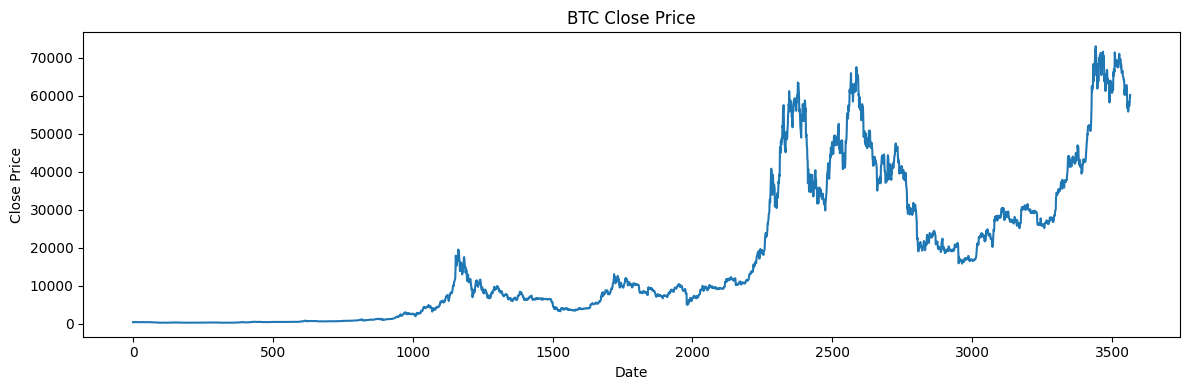

In [43]:
# 2. Basic EDA

# Plot the Close price (detect 'Close' column)
close_col = None
for c in df.columns:
    if 'close' in c.lower():
        close_col = c
        break
if close_col is None:
    raise ValueError("No 'Close' column found. Please ensure the CSV has a Close price column.")

plt.figure(figsize=(12,4))
plt.plot(df[close_col])
plt.title("BTC Close Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.tight_layout()
plt.show()


In [44]:
# 3. Preprocessing: fill missing values and resample to daily

# Convert 'Date' column to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.set_index('Date')

# Forward fill then backfill for safety
df[close_col] = df[close_col].ffill().bfill()

# Resample to daily 'D' (if data already daily this is harmless)
df_daily = df.resample('D').last()
df_daily[close_col] = df_daily[close_col].ffill().bfill()

print("Daily data shape:", df_daily.shape)
display(df_daily[[close_col]].head())

Daily data shape: (3566, 6)


,Close
Date,
2014-10-10,361.562012
2014-10-11,362.299011
2014-10-12,378.549011
2014-10-13,390.414001
2014-10-14,400.869995


In [45]:
# 4. Feature engineering
data = df_daily.copy() # Start with all columns from df_daily
data['log_close'] = np.log(data[close_col])
data['Daily_Return'] = data[close_col].pct_change()
data['MA_7'] = data[close_col].rolling(7).mean()
data['MA_30'] = data[close_col].rolling(30).mean() # New feature
data['Volatility_30'] = data['Daily_Return'].rolling(30).std() # New feature
data['Close_Lag_1'] = data[close_col].shift(1)
data['lag2'] = data[close_col].shift(2) # Kept for GBR compatibility
data['lag3'] = data[close_col].shift(3) # Kept for GBR compatibility

data = data.dropna()
display(data.tail())

,Open,High,Low,Close,Adj Close,Volume,log_close,Daily_Return,MA_7,MA_30,Volatility_30,Close_Lag_1,lag2,lag3
Date,,,,,,,,,,,,,,
2024-07-10,58033.88281,59359.43359,57178.41406,57742.49609,57742.49609,2.617526e+10,10.963749,-0.004598,57178.506697,62260.291147,0.021570,58009.22656,56705.09766,55849.10938
2024-07-11,57729.89063,59299.43359,57120.37891,57344.91406,57344.91406,2.870780e+10,10.956839,-0.006885,57230.965401,61927.387241,0.021031,57742.49609,58009.22656,56705.09766
2024-07-12,57341.19531,58532.55469,56590.17578,57899.46484,57899.46484,2.560481e+10,10.966463,0.009670,57407.692521,61582.663152,0.020926,57344.91406,57742.49609,58009.22656
2024-07-13,57908.73828,59787.07813,57796.44141,59231.95313,59231.95313,1.708006e+10,10.989216,0.023014,57540.323103,61331.848309,0.021301,57899.46484,57344.91406,57742.49609
2024-07-14,59225.25000,60363.85938,59225.25000,60245.80469,60245.80469,2.140587e+10,11.006188,0.017117,58168.422433,61139.672007,0.021586,59231.95313,57899.46484,57344.91406


In [46]:
# 5. Train-test split (time-based)
# Use last 90 days for test set if data long enough, otherwise 80/20
test_days = 90
if len(data) >= 200:
    train = data.iloc[:-test_days]
    test = data.iloc[-test_days:]
else:
    split = int(len(data)*0.8)
    train = data.iloc[:split]
    test = data.iloc[split:]

print("Train length:", len(train), "Test length:", len(test))

Train length: 3446 Test length: 90


XGBoost Model RMSE (Root Mean Squared Error): $617.56


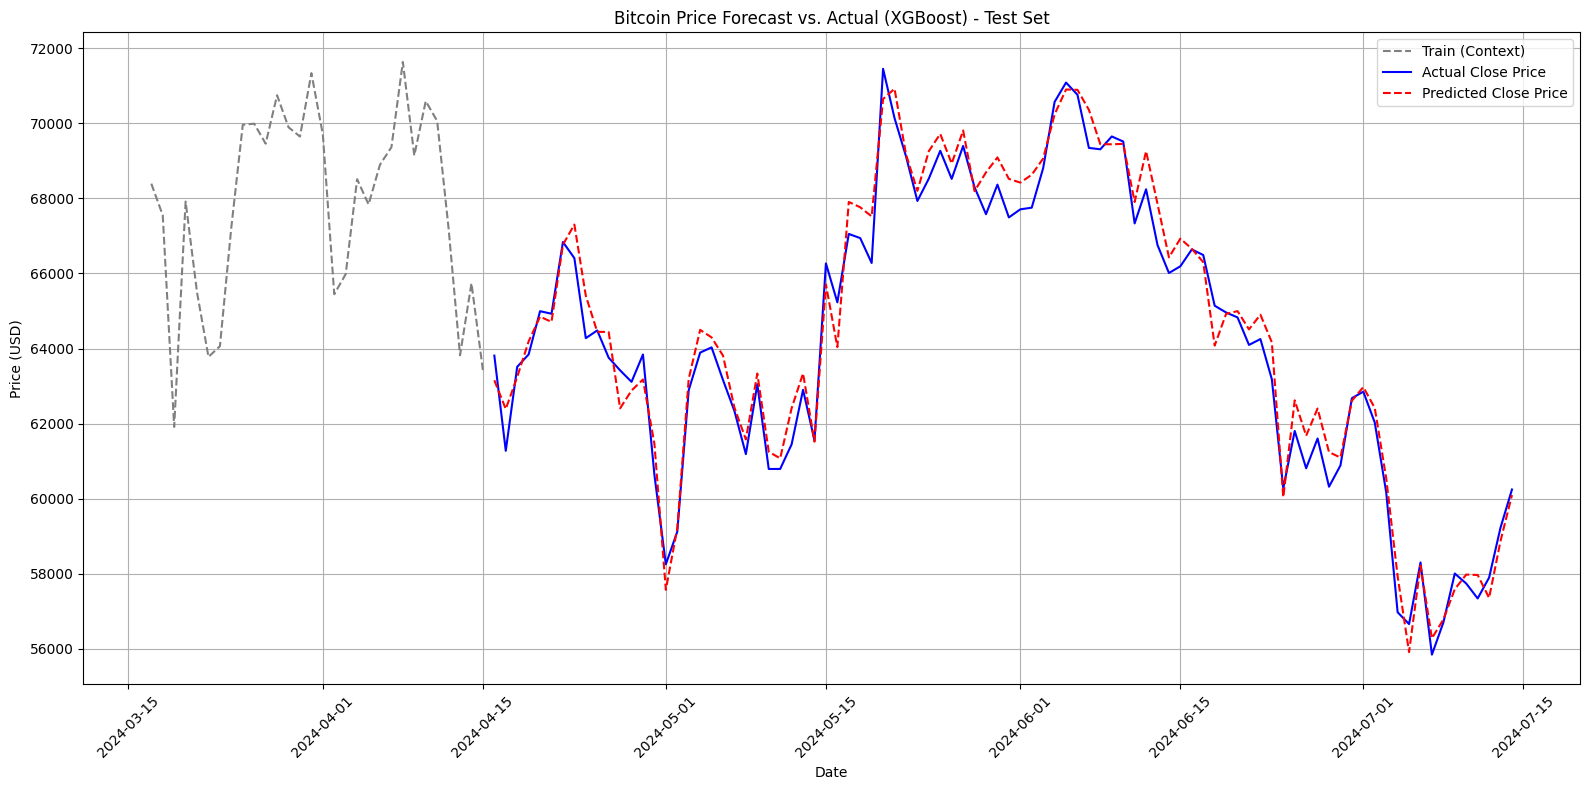


Predictions vs. Actual saved to 'btc_predictions_vs_actual.csv'


In [47]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Prepare Features (X) and Target (y) using the already split train and test dataframes
features = ['Open', 'High', 'Low', 'Volume', 'MA_7', 'MA_30', 'Daily_Return', 'Volatility_30', 'Close_Lag_1']
X_train = train[features]
y_train = train[close_col]
X_test = test[features]
y_test = test[close_col]

# Initialize and Train the XGBoost Regressor Model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror' # Explicitly set objective for regression
)
xgb_model.fit(X_train, y_train)

# Make Predictions
y_pred = xgb_model.predict(X_test)

# 1. Performance Evaluation: Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"XGBoost Model RMSE (Root Mean Squared Error): ${rmse:,.2f}")

# 2. Performance Visualization
# Create a DataFrame for comparison and plotting
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)

# Plotting the last portion of the training data, actual test data, and predictions
plt.figure(figsize=(16, 8))

# Plot the last 30 days of the training set for context
plt.plot(y_train.tail(30), label='Train (Context)', color='gray', linestyle='--')
# Plot the actual values from the test set
plt.plot(predictions_df['Actual'], label='Actual Close Price', color='blue')
# Plot the predicted values
plt.plot(predictions_df['Predicted'], label='Predicted Close Price', color='red', linestyle='--')

plt.title(f'Bitcoin Price Forecast vs. Actual (XGBoost) - Test Set')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('btc_forecast_performance.png')
plt.show()
plt.close()

# Save the predictions to a CSV for a deliverable
predictions_df.to_csv('btc_predictions_vs_actual.csv')
print("\nPredictions vs. Actual saved to 'btc_predictions_vs_actual.csv'")

In [48]:
import statsmodels.api as sm

# ## 8) Model — Simple SARIMA (for comparison)
# SARIMA can be slow; we will fit a compact model on log_close to forecast 1-step ahead.

# %%
# We'll fit SARIMAX on the training Close series
train_series = train['Close']
# Use a very small order to keep it fast. For production run auto_arima (pmdarima) or grid search.
model = sm.tsa.SARIMAX(train_series, order=(1,1,1), seasonal_order=(0,0,0,0), enforce_stationarity=False, enforce_invertibility=False)
res = model.fit(disp=False)
# Forecast for test index range
sarima_forecast = res.get_forecast(steps=len(test)).predicted_mean
# Align index
sarima_forecast.index = test.index
sarima_rmse = np.sqrt(mean_squared_error(y_test, sarima_forecast))
print('SARIMA RMSE:', sarima_rmse)


SARIMA RMSE: 3948.207988026564


In [49]:
# 6. ARIMA model on Close
# Simple ARIMA configuration — (5,1,0) as a starting point
arima_order = (5,1,0)
arima_model = ARIMA(train[close_col], order=arima_order)
arima_res = arima_model.fit()
arima_forecast = arima_res.forecast(steps=len(test))
arima_rmse = np.sqrt(mean_squared_error(test[close_col], arima_forecast))
print("ARIMA RMSE:", arima_rmse)

ARIMA RMSE: 4061.889294992523


In [50]:
# 7. Gradient Boosting using engineered features
features = ['Close_Lag_1','lag2','lag3','MA_7','MA_30','Volatility_30','Daily_Return']
X_train = train[features]
y_train = train[close_col]
X_test = test[features]
y_test = test[close_col]

gbr = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))
print("GBR RMSE:", gbr_rmse)


GBR RMSE: 520.3909003179183


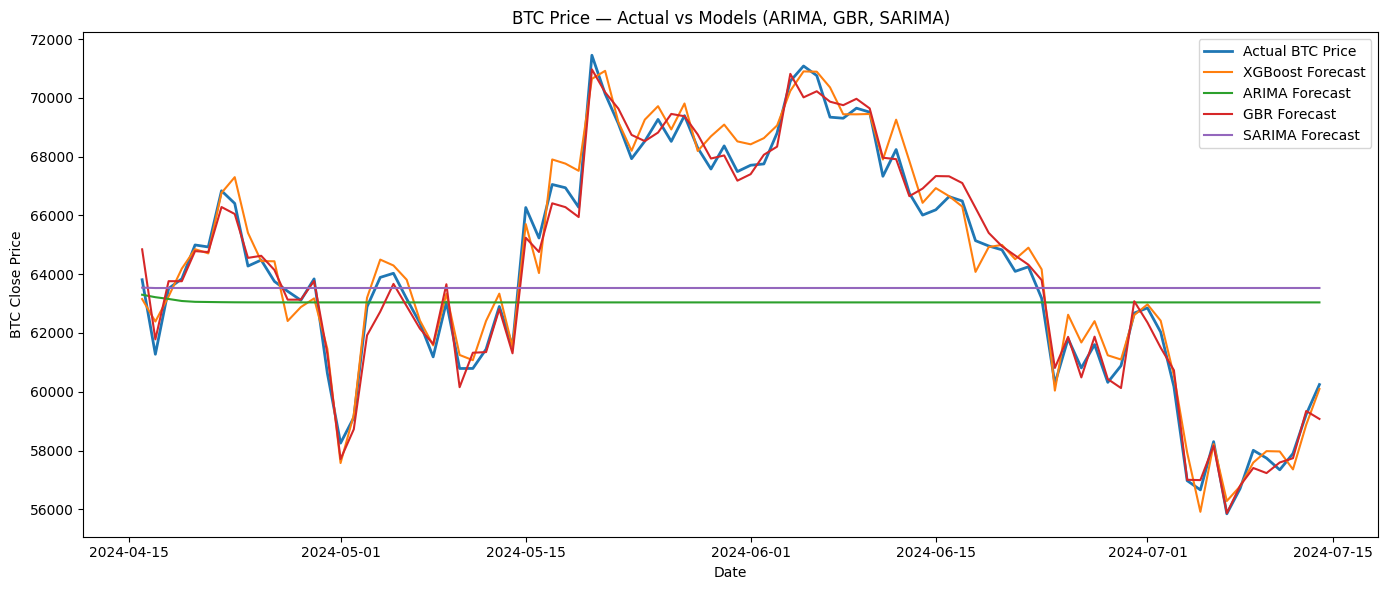

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Add the XGBoost predictions to the comp DataFrame
comp['xgb_pred'] = predictions_df['Predicted']

plt.plot(comp['actual'], label='Actual BTC Price', linewidth=2)
plt.plot(comp['xgb_pred'], label='XGBoost Forecast')
plt.plot(comp['arima_pred'], label='ARIMA Forecast')
plt.plot(comp['gbr_pred'], label='GBR Forecast')
plt.plot(comp['sarima_pred'], label='SARIMA Forecast')

plt.title("BTC Price — Actual vs Models (ARIMA, GBR, SARIMA)")
plt.xlabel("Date")
plt.ylabel("BTC Close Price")
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
# 9. Summary
print("Performance summary:")
print("xGBOOST RMSE:  ${:.2f}".format(rmse))
print(f"ARIMA RMSE: {arima_rmse:.2f}")
print(f"GBR RMSE:   {gbr_rmse:.2f}")
print(f"SARIMA RMSE: {sarima_rmse:.2f}")
# Next steps suggestions:
# - Hyperparameter tuning (GridSearchCV on GBR with TimeSeriesSplit)
# - Try more advanced time-series models: SARIMA, Prophet, LSTM
# - Add external features (on-chain metrics, macro data, Google Trends, BTC volatility indices)
# - Backtest a simple trading rule based on predicted direction/thresholds and measure P&L


Performance summary:
xGBOOST RMSE:  $617.56
ARIMA RMSE: 4061.89
GBR RMSE:   520.39
SARIMA RMSE: 3948.21
